In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
# %cd ..
# %cd xysong
%cd DCCA-Image-Spectrum-Matching

/gpfs/accounts/sunwbgt_root/sunwbgt98/xysong/DCCA-Image-Spectrum-Matching


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
# sys.path.append("../")
from PIL import Image
import os
import torch
import torch.utils.data
import torchvision
# from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm
from icecream import ic
from collections import Counter
from const import *

In [73]:
# filename = r'f15 1800w 1.00beamdia 3v 3 layer z-7 (1Dr).SOMS'
# filename = r'f18 1400w 1.00beamdia 3v 3 layer (2D).SOMS'
# filename = r'f18 1750w 1.00beamdia 6v 3 layer z-7 power1.25 (2B).SOMS'

sname = '2D'
filename = SPECTRA_NAME[sname]
path = os.path.join('Data', 'spectra', filename)
raw = np.loadtxt(open(path, "rb"), delimiter="\t")
print(raw.shape)
# Example rows and cols
# print(raw[0:4,0:8])
# print(raw[2034:2038,0:8])

(2039, 7055)


(2038,)


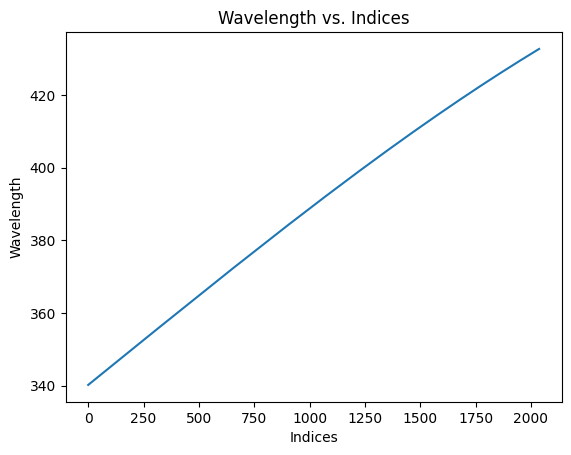

In [74]:
wavelength = raw[1:, 0]
print(wavelength.shape)
plt.plot(wavelength)
plt.xlabel('Indices')
plt.ylabel('Wavelength')
plt.title('Wavelength vs. Indices')
plt.show()
plt.close()

In [75]:
full_spectra = raw[1:, 1:]
# dataset = torch.tensor(full_spectra)
# dataset = (dataset - torch.min(dataset)) / (torch.max(dataset) - torch.min(dataset))
# full_spectra = np.array(dataset)

print(full_spectra.shape)
avg_intensity_across_locations = np.mean(full_spectra, axis = 0)
plt.plot(avg_intensity_across_locations)
plt.axhline(y = 1020, color = 'r', linestyle = '-') 
# plt.axhline(y = 1002, color = 'r', linestyle = '-') 
plt.xlabel("Locations")
plt.ylabel("Average Intensity")
plt.title(f"Average Wavelength Intensity vs. Location ({sname})")

spectra = full_spectra[W_MASK,:]
print(spectra.shape)

print(np.min(full_spectra), np.max(full_spectra))
plt.savefig(f'Document/avg_stat/{sname}-avg-intensity.jpg')
plt.close()

(2038, 7054)
(96, 7054)
934.523 1196.829


In [76]:
threshold = SPECTRA_THRESHOLD[sname]
avg_spectra = avg_intensity_across_locations
up_j, down_j = 0, 0
up_pos, down_pos = np.zeros(3), np.zeros(3)
for i in range(len(avg_spectra) - 1):
    if (avg_spectra[i] > threshold) & (avg_spectra[i - 1] < threshold):
        up_pos[up_j] = i
        up_j += 1
    if (avg_spectra[i] > threshold) & (avg_spectra[i + 1] < threshold):
        down_pos[down_j] = i
        down_j += 1
print(up_pos)
print(down_pos)
print(down_pos - up_pos)
len_spectra = int(min(down_pos - up_pos))
print(len_spectra)

[ 255. 3074. 5901.]
[1047. 3865. 6693.]
[792. 791. 792.]
791


In [77]:
shift_pos = np.floor((down_pos - up_pos - np.ones(3) * len_spectra) / 2).astype(int)
start_pos = up_pos.astype(int) + shift_pos
end_pos = up_pos.astype(int) + shift_pos + np.ones(3).astype(int) * len_spectra
print(start_pos)
print(end_pos)

[ 255 3074 5901]
[1046 3865 6692]


In [78]:
stacked_spectra = np.zeros((full_spectra.shape[0], len_spectra, 3))
stacked_spectra[:, :, 0] = full_spectra[:, start_pos[0]:end_pos[0]]
stacked_spectra[:, :, 1] = np.flip(full_spectra[:, start_pos[1]:end_pos[1]], axis=1)
stacked_spectra[:, :, 2] = full_spectra[:, start_pos[2]:end_pos[2]]
print(stacked_spectra.shape)
avg = stacked_spectra.mean(axis=(0, 2))
print(avg.shape)
plt.plot(avg)
plt.title(f'Average of Average Intensity over 3 Scans ({sname})')
plt.ylabel('Average Intensity')
plt.xlabel('Truncated Locations (only active portion)')
plt.savefig(f'Document/avg_stat/{sname}-avg-of-avg-intensity.jpg')
plt.close()

(2038, 791, 3)
(791,)


In [79]:
avg = stacked_spectra.mean(axis=1)
print(avg.shape)
plt.plot(avg, label=['1st scan', '2nd scan', '3rd scan'])
plt.xlabel('Wavelengths')
plt.ylabel('Average Intensity')
plt.legend()
plt.title(f'Avg Intensity across Active Locations vs. Wavelength for 3 scans ({sname})')
plt.savefig(f'Document/avg_stat/{sname}-avg-intensity-wav.jpg')
plt.close()

(2038, 3)


In [80]:
print(full_spectra.shape)

(2038, 7054)


# Visualization Spectra

In [9]:
%cd DCCA-Image-Spectrum-Matching

[Errno 2] No such file or directory: 'DCCA-Image-Spectrum-Matching'
/gpfs/accounts/sunwbgt_root/sunwbgt98/xysong/DCCA-Image-Spectrum-Matching


In [52]:
import sys
sys.path.append('c:\\Users\\xysong\\Desktop\\Research\\DCCA-Image-Spectrum-Matching')
sys.path.append('../')
from dataset import *
from const import *
from sklearn.model_selection import train_test_split
from models.spec_autoencoder import *

sp = SP(parts=['1Dr'])
dataset = sp.gather(True)
tri_set, val_set = train_test_split(dataset, test_size=0.1, random_state=2023)

>> Reading part 1Dr...
---- Spectra Shape: (2038, 7376)

>> Locating active signals for part 1Dr.
---- The length of active signals is: 942
---- S: [ 272. 3252. 6221.]
---- E: [1225. 4194. 7175.]
---- Processed signal shape: (2038, 942, 3)


 Locating active wavelength for AL7075.
---- Processed signal shape for part 1Dr: (32, 942, 3)
>> Gathering part 1Dr...
---- Spectra Shape: torch.Size([942, 32, 3])


100%|██████████| 942/942 [00:00<00:00, 29035.07it/s]

>> Finished gathering data from parts ['1Dr'].
---- 938 spectra windows of size 5 in total.
---- Data shape: (938, 5, 32)


In [46]:
part = '1Dr'
sp_data = sp.processed_data[part]
print(sp_data.shape)

path = f'Document/spectra_visualization/{part}/'
os.makedirs(path, exist_ok=True)
for idx, spectrum in enumerate(sp_data):
    plt.plot(spectrum.squeeze().cpu().detach().numpy())
    plt.savefig(os.path.join(path, f"spectrum-{idx}.jpg"))
    plt.close()

torch.Size([942, 1, 88])


# Validation

In [4]:
# %cd ..
%cd DCCA-Image-Spectrum-Matching

[Errno 2] No such file or directory: 'DCCA-Image-Spectrum-Matching'
/gpfs/accounts/sunwbgt_root/sunwbgt98/xysong/DCCA-Image-Spectrum-Matching


In [4]:
import sys
sys.path.append('c:\\Users\\xysong\\Desktop\\Research\\DCCA-Image-Spectrum-Matching')
sys.path.append('../')
from dataset import *
from const import *
from sklearn.model_selection import train_test_split
from models.spec_autoencoder import *

sp = SP(parts=['1Dr', '4B', '4D'], normalize=True)
sp = SP(parts=['1Dr'], normalize=True)
dataset = sp.gather_ae(sliding_window=True)
dataset = dataset.unsqueeze(-2)

tri_set, val_set = train_test_split(dataset, test_size=0.1, random_state=2023)

>> Reading part 1Dr...
---- Spectra Shape: (2038, 7376)

>> Reading part 4B...
---- Spectra Shape: (2038, 6759)

>> Reading part 4D...
---- Spectra Shape: (2038, 6859)

>> Locating active signals for part 1Dr.
---- The length of active signals is: 942
---- S: [ 272. 3252. 6221.]
---- E: [1225. 4194. 7175.]
---- Processed signal shape: (2038, 942, 3)

>> Locating active signals for part 4B.
---- The length of active signals is: 681
---- S: [ 246. 2955. 5664.]
---- E: [ 927. 3637. 6346.]
---- Processed signal shape: (2038, 681, 3)

>> Locating active signals for part 4D.
---- The length of active signals is: 682
---- S: [ 223. 2932. 5642.]
---- E: [ 905. 3614. 6324.]
---- Processed signal shape: (2038, 682, 3)


 Locating active wavelength for AL7075.
---- Processed signal shape for part 1Dr: (32, 942, 3)
---- Processed signal shape for part 4B: (32, 681, 3)
---- Processed signal shape for part 4D: (32, 682, 3)
>> Reading part 1Dr...
---- Spectra Shape: (2038, 7376)

>> Locating active s

100%|██████████| 7376/7376 [00:00<00:00, 93601.27it/s]

>> Finished gathering data from parts ['1Dr'].
---- 7372 spectra windows of size 5 in total.
---- Data shape: (7372, 5, 32)


In [6]:
# ckpt_name = '1Dr-4B-4D_na-0'
# ckpt_name = '1Dr-4B-4D_ne'
ckpt_name = '1Dr-4B-4D_na-h=2'
sp_model = SpecAutoEncoder(2)
# sp_model = LinearSpecAutoEncoder()
ckpt_path = os.path.join(CKPT_SAVE_DIR, 'SPAE', f'spec_ae_{ckpt_name}.pt')
pre_trained = torch.load(ckpt_path, map_location=DEVICE)
sp_model.load_state_dict(pre_trained['model'])
print(f'Checkpoint {ckpt_name} loaded successfully!')

Checkpoint 1Dr-4B-4D_na-h=2 loaded successfully!


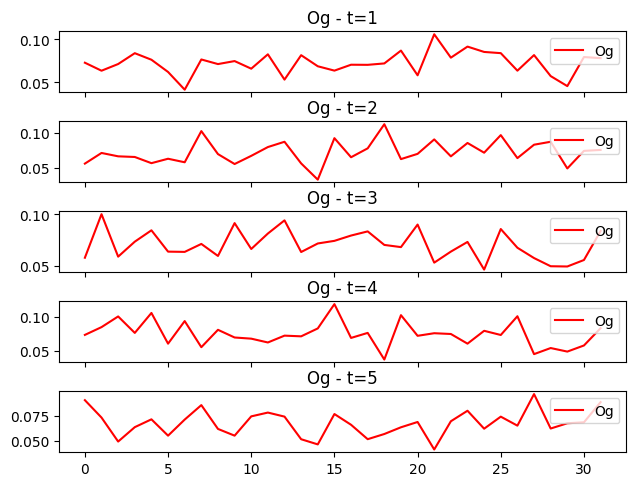

In [14]:
eg = val_set[23]
f, axes = plt.subplots(5, 1, sharex=True, constrained_layout = True)
f.tight_layout()
for idx, ax in enumerate(axes):
    ax.plot(eg[idx].squeeze(), color='red', label='Og')
    ax.legend(loc='upper right')
    ax.set_title(f"Og - t={idx+1}")
plt.show()

torch.Size([5, 1, 32])
tensor([[[-0.3378, -0.2122]]], grad_fn=<PermuteBackward0>)
MSE:  tensor(0.0822)


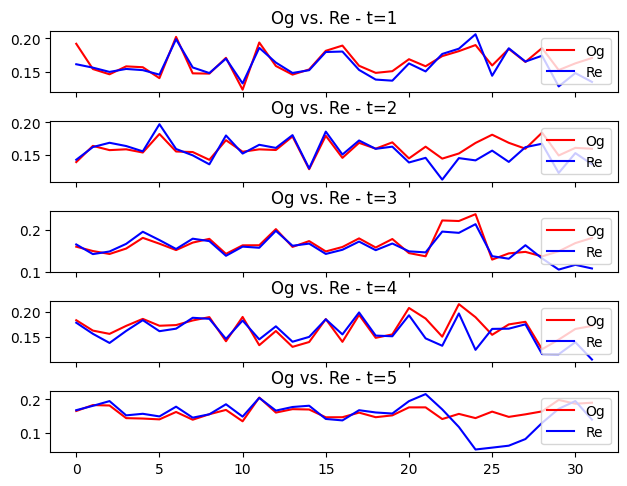

In [7]:
eg = val_set[34]
print(eg.shape)
encoder = sp_model.encoder.to(DEVICE)
print(encoder(eg.unsqueeze(0).to(DEVICE))[0])
sp_model = sp_model.to(DEVICE)
reconstructed_eg = sp_model(eg.unsqueeze(0).to(DEVICE)).squeeze().cpu().detach()
print("MSE: ",F.mse_loss(reconstructed_eg, eg.squeeze(), reduction='sum'))

f, axes = plt.subplots(5, 1, sharex=True, constrained_layout = True)
f.tight_layout()
for idx, ax in enumerate(axes):
    ax.plot(eg[idx].squeeze(), color='red', label='Og')
    ax.plot(reconstructed_eg[idx].squeeze(), color='blue', label='Re')
    ax.legend(loc='upper right')
    ax.set_title(f"Og vs. Re - t={idx+1}")
plt.show()

torch.Size([5, 1, 32])
tensor([[[0.3369, 0.6963]]], grad_fn=<PermuteBackward0>)
MSE:  tensor(0.0329)


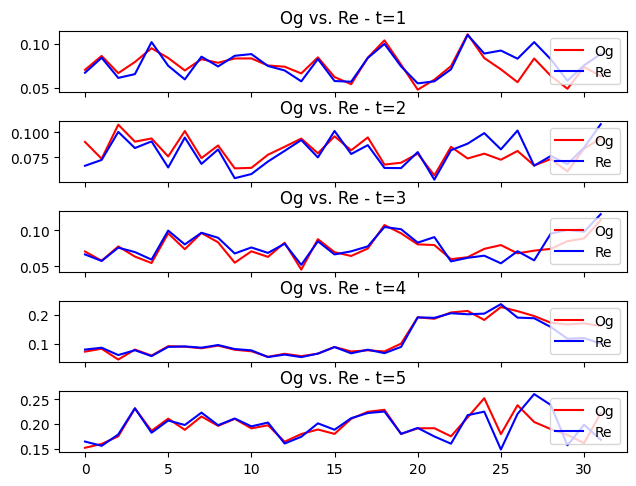

In [8]:
eg = val_set[35]
print(eg.shape)
encoder = sp_model.encoder.to(DEVICE)
print(encoder(eg.unsqueeze(0).to(DEVICE))[0])
sp_model = sp_model.to(DEVICE)
reconstructed_eg = sp_model(eg.unsqueeze(0).to(DEVICE)).squeeze().cpu().detach()
print("MSE: ",F.mse_loss(reconstructed_eg, eg.squeeze(), reduction='sum'))

f, axes = plt.subplots(5, 1, sharex=True, constrained_layout = True)
f.tight_layout()
for idx, ax in enumerate(axes):
    ax.plot(eg[idx].squeeze(), color='red', label='Og')
    ax.plot(reconstructed_eg[idx].squeeze(), color='blue', label='Re')
    ax.legend(loc='upper right')
    ax.set_title(f"Og vs. Re - t={idx+1}")
plt.show()

### Validation on aligned data

In [11]:
print('Dataset Test Suites.')

# Spectra data
with torch.no_grad():
    # Test spectra class
    sp = SP(parts=['1Dr', '4B', '4D'], normalize=True)
    sp.gather(False)

    ct = CT(['1Dr'])
    ct.read()
    ct.gather()

    aligner = Aligner(['1Dr'], ct, sp)
    aligner.align(0.20)
    data = aligner.aligned_raw['1Dr']
    for item in data:
        print((item[0].shape, item[1].shape))

Dataset Test Suites.
>> Reading part 1Dr...
---- Spectra Shape: (2038, 7376)

>> Reading part 4B...
---- Spectra Shape: (2038, 6759)

>> Reading part 4D...
---- Spectra Shape: (2038, 6859)

>> Locating active signals for part 1Dr.
---- The length of active signals is: 942
---- S: [ 272. 3252. 6221.]
---- E: [1225. 4194. 7175.]
---- Processed signal shape: (2038, 942, 3)

>> Locating active signals for part 4B.
---- The length of active signals is: 681
---- S: [ 246. 2955. 5664.]
---- E: [ 927. 3637. 6346.]
---- Processed signal shape: (2038, 681, 3)

>> Locating active signals for part 4D.
---- The length of active signals is: 682
---- S: [ 223. 2932. 5642.]
---- E: [ 905. 3614. 6324.]
---- Processed signal shape: (2038, 682, 3)


 Locating active wavelength for AL7075.
---- Processed signal shape for part 1Dr: (32, 942, 3)
---- Processed signal shape for part 4B: (32, 681, 3)
---- Processed signal shape for part 4D: (32, 682, 3)
>> Gathering part 1Dr...
---- Spectra Shape: torch.Size(

100%|██████████| 4046/4046 [01:25<00:00, 47.33it/s]


Finished gathering data from parts: ['1Dr'].
4046 CT scan images in total.
(torch.Size([23, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([6, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([6, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([6, 32, 3]))
(torch.Size([24, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([6, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([6, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([5, 32, 3]))
(torch.Size([23, 1, 250, 730]), torch.Size([6, 32, 3]))
(torch.Size([24, 1, 250, 730]

torch.Size([5, 1, 32])
tensor([[[ 0.9932,  0.9973,  0.1269, -0.8205,  0.9963,  0.7466,  0.1990,
          -0.9970, -0.0358,  0.9743,  0.0034,  0.0053,  0.9948, -0.2277,
           0.3984,  0.9976]]], grad_fn=<PermuteBackward0>)
MSE:  tensor(0.0142)


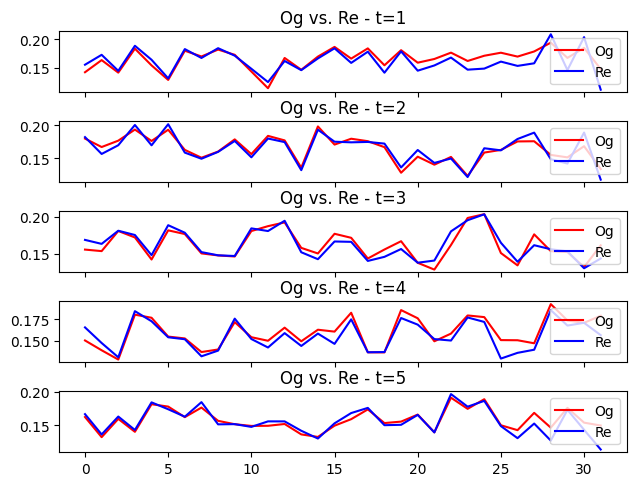

In [16]:
eg = data[0][1][:,:, 0].unsqueeze(1)
print(eg.shape)
encoder = sp_model.encoder.to(DEVICE)
print(encoder(eg.unsqueeze(0).to(DEVICE))[0])
sp_model = sp_model.to(DEVICE)
reconstructed_eg = sp_model(eg.unsqueeze(0).to(DEVICE)).squeeze().cpu().detach()
print("MSE: ",F.mse_loss(reconstructed_eg, eg.squeeze(), reduction='sum'))

f, axes = plt.subplots(5, 1, sharex=True, constrained_layout = True)
f.tight_layout()
for idx, ax in enumerate(axes):
    ax.plot(eg[idx].squeeze(), color='red', label='Og')
    ax.plot(reconstructed_eg[idx].squeeze(), color='blue', label='Re')
    ax.legend(loc='upper right')
    ax.set_title(f"Og vs. Re - t={idx+1}")
plt.show()
